In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized_sinbeta_sparse import TVqRegularized
from bimpcc.models.tvq_denoising_sinbeta import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from bimpcc.utils import generate_2D_gradient_matrices

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title(f'Noisy Image\nPSNR: {psnr(true,noisy):.4f}'.format())
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')

    plt.show()
    
    return psnr(true,noisy), psnr(true,u)

In [4]:
scale = 128

In [5]:
name_exp = "guacamayo"
dataset = get_dataset(name_exp,scale=scale, random_state=1)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

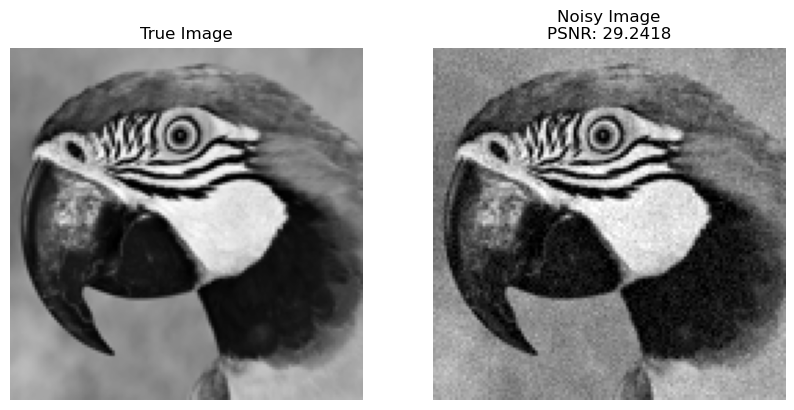

In [6]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [7]:
q_param = 0.99
model = TVqRegularized(true, noisy, epsilon=1e-3, q_param=q_param)

In [8]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)

[100.]
[100.]
[100.]
[99.55913781]
[93.36992687]
[91.49910211]
[91.07424202]
[90.57996247]
[78.40188504]
[77.34178199]
[68.22849405]
[66.80619547]
[58.79256342]
[60.69972429]
[60.54385634]
[60.51196861]
[60.46404054]
[60.46816979]
[60.47310813]
[60.47866368]
[60.47822101]
[60.49137119]
[60.48572739]
[60.48373038]
[60.48379661]


In [9]:
print(open("ipopt.log", "r", encoding="utf-8", errors="ignore").read()[:5000])


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:   835388
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:    48897
                     variables with only lower bounds:    16385
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    48896
Total number of inequality c

In [12]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

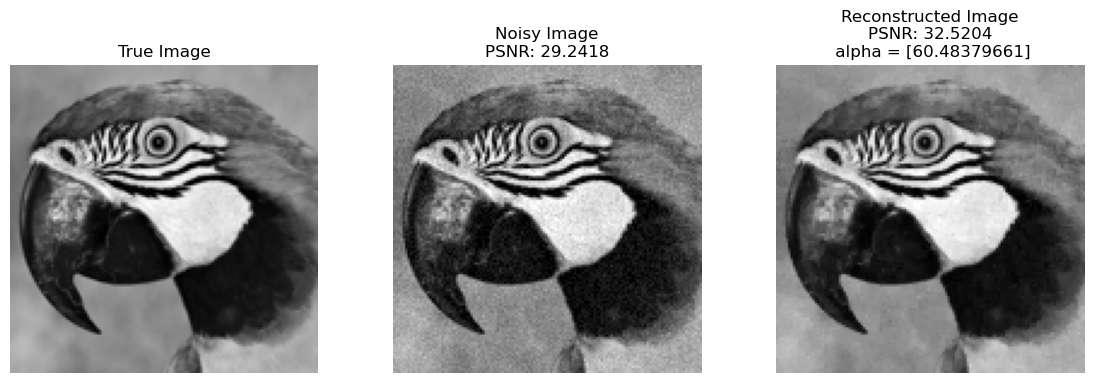

In [13]:
u_scaled = u.reshape((scale,scale))
psnr_n, psnr_r = plot_experiment(true,noisy,u_scaled,alpha)

In [18]:
from pathlib import Path
from imageio import imwrite

In [19]:

out_dir = Path("results_tvq") / "guacamayo"   # <- dos carpetas
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"true_{name_exp}_{scale}.png"
imwrite(str(out_path), (true * 255).astype(np.uint8))

In [ ]:
out_path = out_dir / f"noisy_{name_exp}_{scale}_{psnr_n:.4f}.png"
imwrite(str(out_path), (noisy * 255).astype(np.uint8))

In [ ]:
out_path = out_dir / f"recons_{name_exp}_{scale}_{psnr_r:.4f}_{alpha[0]:.2f}.png"
imwrite(str(out_path), (u_scaled * 255).astype(np.uint8))